### PSMNIST with LMU

In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from psmnist_task import PSMNISTTask
from src.train_utils.trainer import Trainer
from src.models.v2.build_model import BlockConfig

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
A `create_block_cfg_ctor` function is defined to generate model block configurations dynamically,
allowing for easy switching between LMU and S4 models.

In [3]:
def create_block_cfg_ctor(kind: str, dropout: float, mlp_ratio: float, droppath_final: float,
                          layerscale_init: float, residual_gain: float, pool: str, **kwargs):
    """Create a block config constructor with the given hyperparameters."""
    def block_cfg_ctor(theta: int) -> BlockConfig:
        return BlockConfig(
            kind=kind,
            memory_size=256,
            theta=theta,
            dropout=dropout,
            mlp_ratio=mlp_ratio,
            droppath_final=droppath_final,
            layerscale_init=layerscale_init,
            residual_gain=residual_gain,
            pool=pool,
            **kwargs
        )
    return block_cfg_ctor


In [4]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "psmnist" / "data")

args: Dict[str, Any] = {
    # data
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },

    # training
    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/psmnist_lmu_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    # model scaffold
    "d_model": 128,
    "depth": 2,
    "dropout": 0.1,  # ⬇️ Less dropout for simpler task
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",
}

args["block_cfg_ctor"] = create_block_cfg_ctor(
    kind="lmu",
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("🚀 Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False

🚀 Using MPS


### Training
With the configuration set up, we can now instantiate the `PSMNISTTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [5]:
import matplotlib.pyplot as plt

def plot_history(history):

    plt.figure(figsize=(12, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
task = PSMNISTTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)


/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: divide by zero encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: overflow encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:326: RuntimeWarning: invalid value encountered in matmul
  m, s = pick_pade_structure(Am)
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: divide by zero encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/linalg/_matfuncs.py:358: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/glbrlb/PycharmProjects/Msc/LMU_S4/.venv/lib/python3.9/site-packages/scipy/li

✅ Loaded checkpoint from epoch 24
📊 Val metrics: {'loss': 0.14989372519329192, 'time_s': 29.88077812499978, 'acc': 0.9624}


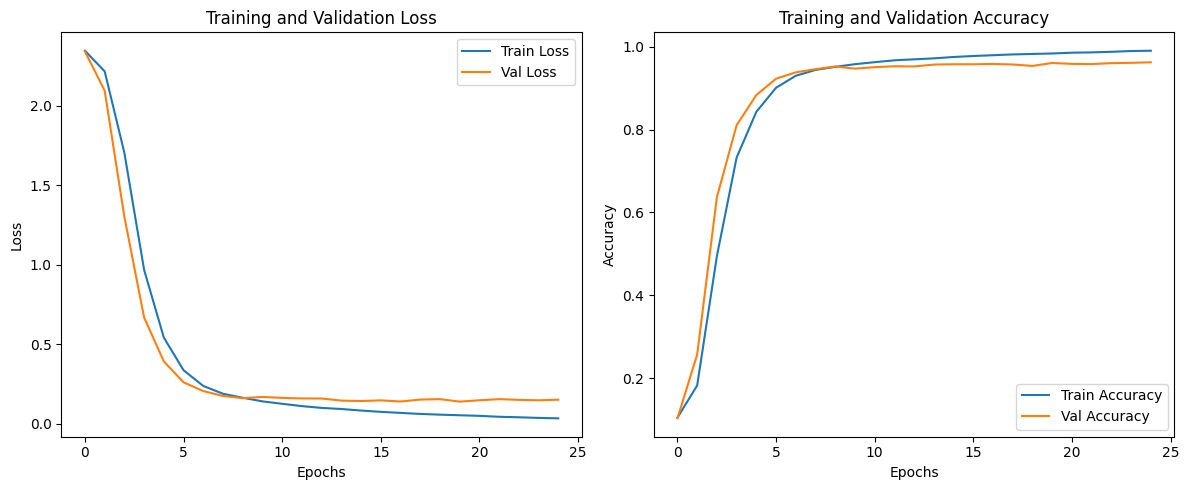

In [6]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=PSMNISTTask(),
)

history = trainer.history

plot_history(history)

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

In [ ]:
from src.notebooks.psmnist.psmnist_eval import evaluate_best_model, print_evaluation_results

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=PSMNISTTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
)

print_evaluation_results(
    logits_test=logits_test,
    labels_test=labels_test,
)

### Changes in dataset length


🔄 Training with fraction: 0.25
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
   Applying data fraction: 25.0%
   Original train size: 60000
   Original val size: 10000
   Reduced train size: 14995
   Reduced val size: 10000
   Test size: 10000 (unchanged)


💾 saved best model to ./runs/psmnist_lmu_task_frac_0.25/best.pt
✅ new best acc 0.1010
Epoch 000/50 | train 2.3856/0.1021 | val 2.3851/0.1010 | t 155.8s/30.4s | lr 1.00e-06


💾 saved best model to ./runs/psmnist_lmu_task_frac_0.25/best.pt
✅ new best acc 0.1790
Epoch 001/50 | train 2.2914/0.1257 | val 2.2641/0.1790 | t 144.2s/29.0s | lr 2.01e-04


💾 saved best model to ./runs/psmnist_lmu_task_frac_0.25/best.pt
✅ new best acc 0.2256
Epoch 002/50 | train 2.2268/0.1878 | val 2.1804/0.2256 | t 146.1s/29.0s | lr 4.01e-04


💾 saved best model to ./runs/psmnist_lmu_task_frac_0.25/best.pt
✅ new best acc 0.4331
Epoch 003/50 | train 2.0427/0.3164 | val 1.8586/0.4331 | t 139.4s/26.1s | lr 6.00e-04


...

Epoch 024/50 | train 0.0558/0.9848 | val 0.2290/0.9379 | t 128.2s/25.5s | lr 6.21e-04


Epoch 025/50 | train 0.0512/0.9866 | val 0.2266/0.9395 | t 127.1s/25.4s | lr 5.87e-04


Epoch 026/50 | train 0.0430/0.9900 | val 0.2223/0.9391 | t 126.8s/25.4s | lr 5.52e-04


Epoch 027/50 | train 0.0386/0.9909 | val 0.2319/0.9375 | t 127.0s/25.1s | lr 5.17e-04


⏹ Early stopping (patience=5, best=0.9414).
📊 Training history saved to ./runs/psmnist_lmu_task_frac_0.25/history.json

✅ Training complete for fraction 0.25! Best validation acc: 0.9414
💾 Best model saved to: ./runs/psmnist_lmu_task_frac_0.25/best.pt


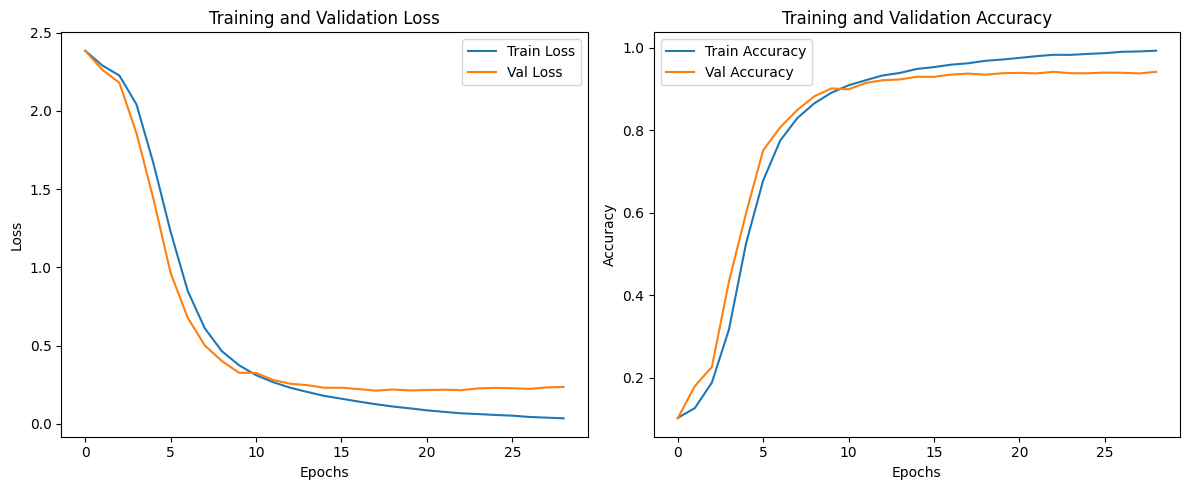

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
   Applying data fraction: 25.0%
   Original train size: 60000
   Original val size: 10000
   Reduced train size: 14995
   Reduced val size: 10000
   Test size: 10000 (unchanged)
✅ Loaded checkpoint from epoch 22
📊 Val metrics: {'loss': 0.2142016890179366, 'time_s': 24.97869779199982, 'acc': 0.9414}
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)


Evaluating on test set: 100%|██████████| 79/79 [00:25<00:00,  3.11it/s]



✅ Test results saved to: runs/psmnist_lmu_task_frac_0.25/test_results.json
   Test Accuracy: 0.9414 (94.14%)
   Test Loss: 0.2142

TEST SET RESULTS:
Accuracy: 0.9414
Class 00: 0.9735
Class 01: 0.9806
Class 02: 0.9409
Class 03: 0.9178
Class 04: 0.9409
Class 05: 0.9170
Class 06: 0.9551
Class 07: 0.9494
Class 08: 0.9322
Class 09: 0.8999

🔄 Training with fraction: 0.5
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
   Applying data fraction: 50.0%
   Original train size: 60000
   Original val size: 10000
   Reduced train size: 29997
   Reduced val size: 10000
   Test size: 10000 (unchanged)


💾 saved best model to ./runs/psmnist_lmu_task_frac_0.5/best.pt
✅ new best acc 0.1009
Epoch 000/50 | train 2.3793/0.0992 | val 2.3744/0.1009 | t 251.0s/25.1s | lr 1.00e-06


💾 saved best model to ./runs/psmnist_lmu_task_frac_0.5/best.pt
✅ new best acc 0.1742
Epoch 001/50 | train 2.2633/0.1411 | val 2.2216/0.1742 | t 251.5s/24.8s | lr 2.01e-04


...

Epoch 017/50 | train 0.0729/0.9774 | val 0.1984/0.9456 | t 253.9s/24.9s | lr 8.35e-04


Epoch 018/50 | train 0.0636/0.9801 | val 0.2147/0.9420 | t 252.2s/25.0s | lr 8.08e-04


Epoch 019/50 | train 0.0583/0.9820 | val 0.2006/0.9464 | t 254.9s/25.4s | lr 7.80e-04


Epoch 020/50 | train 0.0509/0.9841 | val 0.1994/0.9464 | t 251.9s/24.8s | lr 7.50e-04


⏹ Early stopping (patience=5, best=0.9475).
📊 Training history saved to ./runs/psmnist_lmu_task_frac_0.5/history.json

✅ Training complete for fraction 0.5! Best validation acc: 0.9475
💾 Best model saved to: ./runs/psmnist_lmu_task_frac_0.5/best.pt


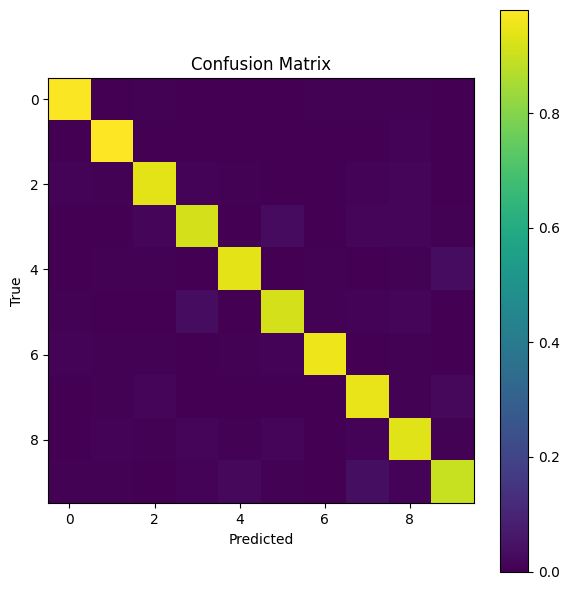

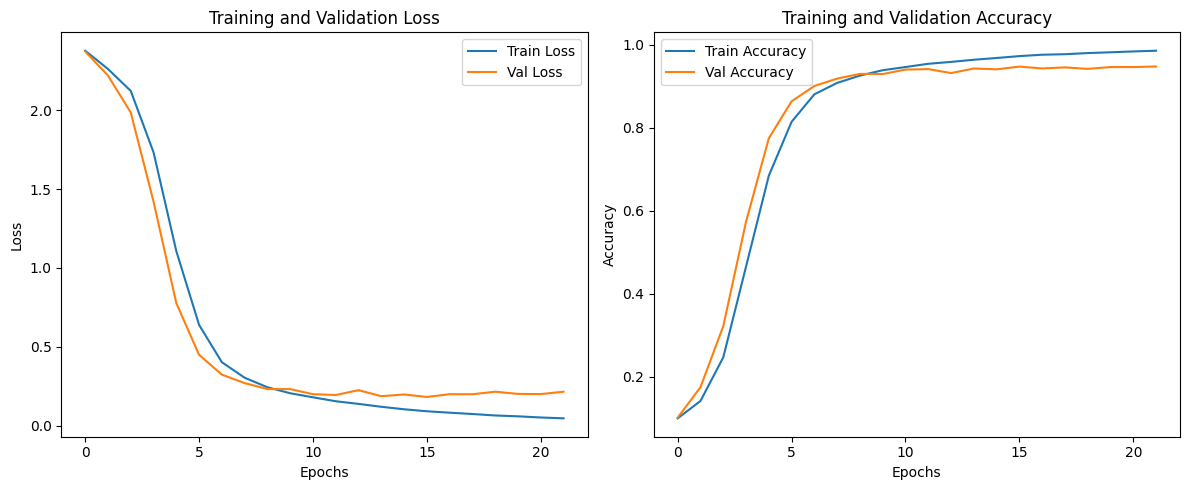

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
   Applying data fraction: 50.0%
   Original train size: 60000
   Original val size: 10000
   Reduced train size: 29997
   Reduced val size: 10000
   Test size: 10000 (unchanged)
✅ Loaded checkpoint from epoch 15
📊 Val metrics: {'loss': 0.18106582358181478, 'time_s': 25.83043416699911, 'acc': 0.9475}
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)


Evaluating on test set: 100%|██████████| 79/79 [00:26<00:00,  3.03it/s]



✅ Test results saved to: runs/psmnist_lmu_task_frac_0.5/test_results.json
   Test Accuracy: 0.9475 (94.75%)
   Test Loss: 0.1811

TEST SET RESULTS:
Accuracy: 0.9475
Class 00: 0.9796
Class 01: 0.9824
Class 02: 0.9486
Class 03: 0.9317
Class 04: 0.9562
Class 05: 0.9193
Class 06: 0.9415
Class 07: 0.9329
Class 08: 0.9415
Class 09: 0.9346


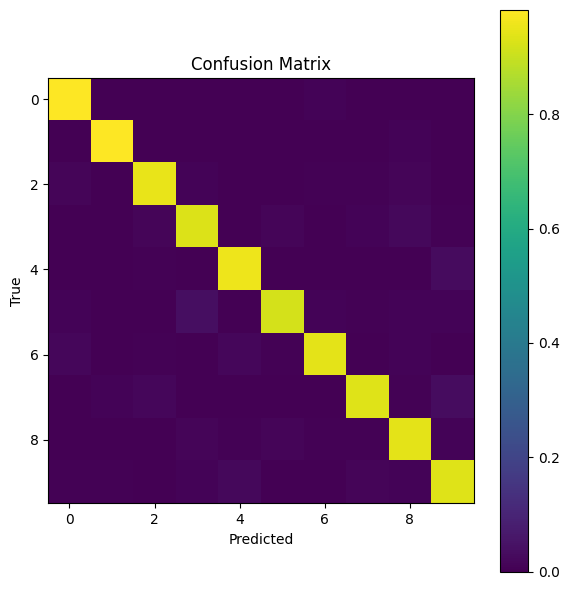

In [7]:
from src.train_utils.trainer import Trainer
import matplotlib.pyplot as plt
from src.notebooks.psmnist.psmnist_eval import evaluate_best_model, print_evaluation_results

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"


for frac in [0.1, 0.25, 0.5]:
    print(f"\nTraining with fraction: {frac}")

    args["fraction"] = frac
    args["save_dir"] = f"./runs/psmnist_lmu_task_frac_{frac}"
    trainer = Trainer(args=args, task=PSMNISTTask())
    best_metric, best_path = trainer.fit()

    print(f"\nTraining complete for fraction {frac}! Best validation {trainer.early_key}: {best_metric:.4f}")
    print(f"Best model saved to: {best_path}")

    history = trainer.history

    plot_history(history)

    logits_test, labels_test = evaluate_best_model(
        args=args,
        task=PSMNISTTask(),
        best_model_path=best_path
    )

    print_evaluation_results(
    logits_test=logits_test,
    labels_test=labels_test,
)